In [1]:
!pip install -q \
transformers==4.46.3 \
peft==0.13.2 \
trl==0.11.4 \
accelerate \
datasets \
bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import torch
import random
import numpy as np
from datasets import Dataset
from transformers import set_seed

# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv")

df.head()

,instruction,output,input
0,Give three tips for staying healthy.,1. Eat a balanced and nutritious diet: Make su...,NaN
1,What are the three primary colors?,"The three primary colors are red, blue, and ye...",NaN
2,Describe the structure of an atom.,An atom is the basic building block of all mat...,NaN
3,How can we reduce air pollution?,There are several ways to reduce air pollution...,NaN
4,Pretend you are a project manager of a constru...,I had to make a difficult decision when I was ...,NaN


In [4]:
print(df.columns)
print(df.shape)

Index(['instruction', 'output', 'input'], dtype='object')
(51760, 3)


In [5]:
df.isnull().sum()

instruction        0
output             0
input          32618
dtype: int64

In [6]:
df = df.fillna("")

In [7]:
dataset = Dataset.from_pandas(df)

In [8]:
def create_messages(example):
    user_message = example["instruction"]

    if example["input"].strip():
        user_message += "\n\n" + example["input"]

    return {
        "messages": [
            {
                "role": "user",
                "content": user_message,
            },
            {
                "role": "assistant",
                "content": example["output"],
            },
        ]
    }

In [9]:
dataset = dataset.map(create_messages)

Map:   0%|          | 0/51760 [00:00<?, ? examples/s]

In [10]:
dataset[0]["messages"]

[{'role': 'user', 'content': 'Give three tips for staying healthy.'},
 {'role': 'assistant',
  'content': '1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.'}]

In [11]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)

from peft import (
    LoraConfig,
)

from trl import (
    SFTTrainer,
    SFTConfig,
)

In [12]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [13]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((

In [14]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ]
)

In [15]:
from peft import get_peft_model

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


In [16]:
#cell 10
def apply_chat_template(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

In [17]:
dataset = dataset.map(apply_chat_template)

Map:   0%|          | 0/51760 [00:00<?, ? examples/s]

In [18]:
print(dataset[0]["text"])

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Give three tips for staying healthy.<|im_end|>
<|im_start|>assistant
1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.

2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.

3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.<|im_end|>



In [19]:
dataset = dataset.remove_columns(
    ["instruction", "input", "output", "messages"]
)

In [20]:
dataset = dataset.train_test_split(
    test_size=0.1,
    seed=SEED,
)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

In [21]:
# Use only the first 5,000 training samples
train_dataset = train_dataset.select(range(5000))

print(f"Training examples   : {len(train_dataset)}")
print(f"Validation examples : {len(val_dataset)}")

Training examples   : 5000
Validation examples : 5176


In [22]:
print(train_dataset)
print(val_dataset)

Dataset({
    features: ['text'],
    num_rows: 5000
})
Dataset({
    features: ['text'],
    num_rows: 5176
})


In [23]:
training_args = SFTConfig(
    output_dir="./qwen_lora",

    num_train_epochs=2,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,

    fp16=True,

    logging_steps=50,

    eval_strategy="epoch",

    save_strategy="epoch",

    report_to="tensorboard",

    logging_dir="./logs",

    warmup_ratio=0.03,

    lr_scheduler_type="cosine",

    max_seq_length=512,

    dataset_text_field="text",
    seed=SEED,
)

In [24]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    args=training_args,
)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5176 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:401: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(


In [25]:
%load_ext tensorboard
%tensorboard --logdir ./logs

<IPython.core.display.Javascript object>

In [26]:
trainer.train()

Epoch,Training Loss,Validation Loss
0,1.221000,1.209821
1,1.163800,1.207713


TrainOutput(global_step=624, training_loss=1.2046254567610912, metrics={'train_runtime': 1095.847, 'train_samples_per_second': 9.125, 'train_steps_per_second': 0.569, 'total_flos': 7081053629337600.0, 'train_loss': 1.2046254567610912, 'epoch': 1.9968})

In [27]:
trainer.model.save_pretrained("./qwen_lora_adapter")
tokenizer.save_pretrained("./qwen_lora_adapter")

('./qwen_lora_adapter/tokenizer_config.json',
 './qwen_lora_adapter/special_tokens_map.json',
 './qwen_lora_adapter/vocab.json',
 './qwen_lora_adapter/merges.txt',
 './qwen_lora_adapter/added_tokens.json',
 './qwen_lora_adapter/tokenizer.json')

In [28]:
import os

print(os.listdir("./qwen_lora_adapter"))

['merges.txt', 'special_tokens_map.json', 'tokenizer.json', 'adapter_model.safetensors', 'README.md', 'tokenizer_config.json', 'added_tokens.json', 'vocab.json', 'adapter_config.json']


In [29]:
eval_results = trainer.evaluate()

print(eval_results)

{'eval_loss': 1.2077127695083618, 'eval_runtime': 183.7024, 'eval_samples_per_second': 28.176, 'eval_steps_per_second': 3.522, 'epoch': 1.9968}


In [30]:
import math

perplexity = math.exp(eval_results["eval_loss"])

print(f"Perplexity: {perplexity:.2f}")

Perplexity: 3.35


In [31]:
%load_ext tensorboard
%tensorboard --logdir ./logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 164), started 0:21:21 ago. (Use '!kill 164' to kill it.)

<IPython.core.display.Javascript object>

In [32]:
%tensorboard --logdir ./logs

Reusing TensorBoard on port 6006 (pid 164), started 0:21:21 ago. (Use '!kill 164' to kill it.)

<IPython.core.display.Javascript object>

In [33]:
%reload_ext tensorboard
%tensorboard --logdir ./logs

Reusing TensorBoard on port 6006 (pid 164), started 0:21:21 ago. (Use '!kill 164' to kill it.)

<IPython.core.display.Javascript object>

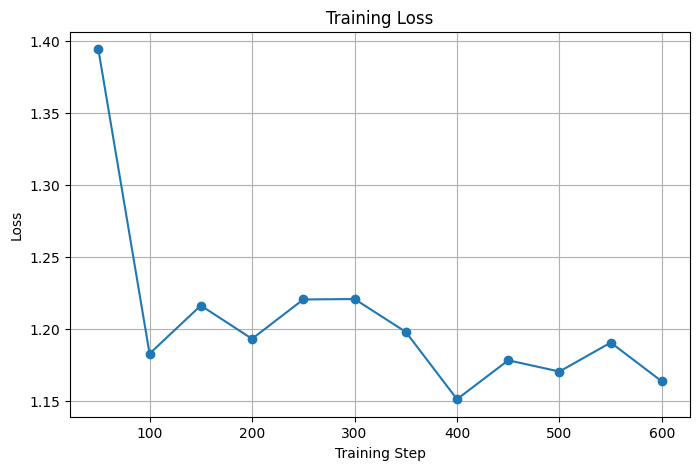

In [34]:
import matplotlib.pyplot as plt

train_logs = [x for x in trainer.state.log_history if "loss" in x]

steps = [x["step"] for x in train_logs]
losses = [x["loss"] for x in train_logs]

plt.figure(figsize=(8,5))
plt.plot(steps, losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

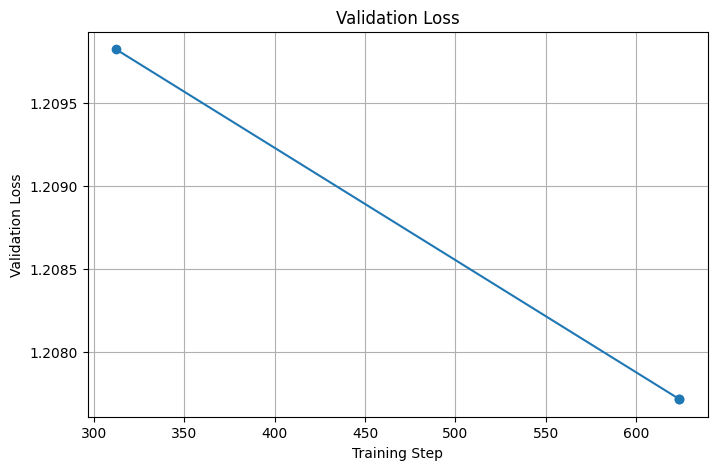

In [35]:
eval_logs = [x for x in trainer.state.log_history if "eval_loss" in x]

steps = [x["step"] for x in eval_logs]
eval_loss = [x["eval_loss"] for x in eval_logs]

plt.figure(figsize=(8,5))
plt.plot(steps, eval_loss, marker="o")
plt.title("Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

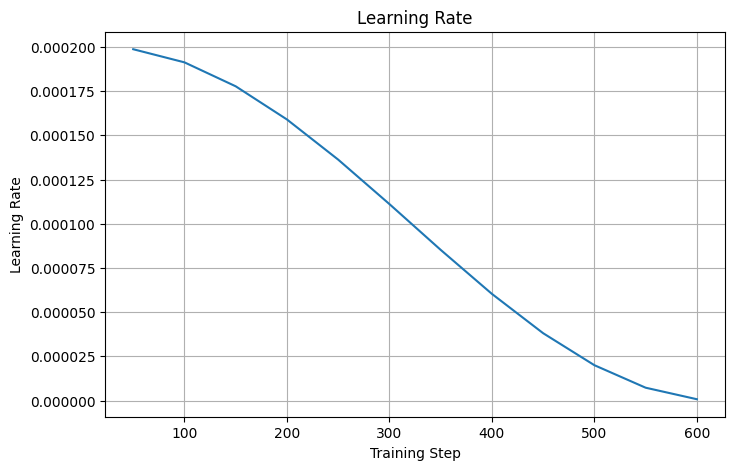

In [36]:
lr_logs = [x for x in trainer.state.log_history if "learning_rate" in x]

if lr_logs:
    steps = [x["step"] for x in lr_logs]
    lrs = [x["learning_rate"] for x in lr_logs]

    plt.figure(figsize=(8,5))
    plt.plot(steps, lrs)
    plt.title("Learning Rate")
    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.show()

In [37]:
trainer.state.log_history

[{'loss': 1.3943,
  'grad_norm': 0.5228574872016907,
  'learning_rate': 0.00019870716120959462,
  'epoch': 0.16,
  'step': 50},
 {'loss': 1.1831,
  'grad_norm': 0.5040300488471985,
  'learning_rate': 0.00019128400669818585,
  'epoch': 0.32,
  'step': 100},
 {'loss': 1.2165,
  'grad_norm': 0.5376100540161133,
  'learning_rate': 0.0001777418212147079,
  'epoch': 0.48,
  'step': 150},
 {'loss': 1.1934,
  'grad_norm': 0.4613775908946991,
  'learning_rate': 0.00015898837661756406,
  'epoch': 0.64,
  'step': 200},
 {'loss': 1.2207,
  'grad_norm': 0.39448416233062744,
  'learning_rate': 0.0001362807705350641,
  'epoch': 0.8,
  'step': 250},
 {'loss': 1.221,
  'grad_norm': 0.4497443437576294,
  'learning_rate': 0.00011114115947573833,
  'epoch': 0.96,
  'step': 300},
 {'eval_loss': 1.2098214626312256,
  'eval_runtime': 184.5743,
  'eval_samples_per_second': 28.043,
  'eval_steps_per_second': 3.505,
  'epoch': 0.9984,
  'step': 312},
 {'loss': 1.1982,
  'grad_norm': 0.4687861204147339,
  'learn

In [38]:
merged_model = trainer.model.merge_and_unload()

In [39]:
merged_model.save_pretrained("./qwen_merged")
tokenizer.save_pretrained("./qwen_merged")

('./qwen_merged/tokenizer_config.json',
 './qwen_merged/special_tokens_map.json',
 './qwen_merged/vocab.json',
 './qwen_merged/merges.txt',
 './qwen_merged/added_tokens.json',
 './qwen_merged/tokenizer.json')

In [40]:
import os

print(os.listdir("./qwen_merged"))

['merges.txt', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'config.json', 'model.safetensors', 'added_tokens.json', 'generation_config.json', 'vocab.json']


In [41]:
!zip -r qwen_merged.zip qwen_merged

  adding: qwen_merged/ (stored 0%)
  adding: qwen_merged/merges.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 57%)
  adding: qwen_merged/special_tokens_map.json (deflated 69%)
  adding: qwen_merged/tokenizer.json (deflated 81%)
  adding: qwen_merged/tokenizer_config.json (deflated 83%)
  adding: qwen_merged/config.json (deflated 47%)
  adding: qwen_merged/model.safetensors (deflated 22%)
  adding: qwen_merged/added_tokens.json (deflated 67%)
  adding: qwen_merged/generation_config.json (deflated 39%)
  adding: qwen_merged/vocab.json (deflated 61%)
